In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
import warnings
from typing import Dict, List, Tuple, Optional
from scipy.optimize import differential_evolution
from scipy.stats import qmc
import flopy
import joblib
import time

warnings.filterwarnings('ignore')

In [2]:
# =============================================================================
# 1. ENHANCED CONFIGURATION
# =============================================================================
class EnhancedMODFLOWConfig:
    """Enhanced configuration with time-varying parameters."""
    
    def __init__(
        self,
        model_name: str = 'gwl_model',
        model_ws: str = 'modflow_workspace',
        exe_name: str = 'mf2005',
        # Grid parameters
        nlay: int = 2,  # Multiple layers for better vertical flow
        nrow:  int = 15,
        ncol: int = 15,
        delr: float = 500.0,  # Finer grid
        delc: float = 500.0,
        # Layer properties
        top: float = 100.0,
        botm: List[float] = None,
        # Aquifer properties (will be calibrated)
        hk: float = 10.0,
        vka: float = 0.1,  # Vertical anisotropy
        sy: float = 0.15,
        ss: float = 1e-5,
        laytyp: List[int] = None,
        # Initial/boundary conditions
        strt: float = 88.0,
        # Observation well location
        well_row: int = 7,
        well_col: int = 7,
        # Reference elevation
        reference_elevation: float = 100.0,
    ):
        self.model_name = model_name
        self.model_ws = model_ws
        self.exe_name = exe_name
        self.nlay = nlay
        self.nrow = nrow
        self.ncol = ncol
        self. delr = delr
        self.delc = delc
        self.top = top
        self. botm = botm if botm else [50.0, 0.0]  # Two layers
        self.hk = hk
        self.vka = vka
        self.sy = sy
        self.ss = ss
        self. laytyp = laytyp if laytyp else [1, 0]  # Unconfined, confined
        self.strt = strt
        self.well_row = well_row
        self.well_col = well_col
        self.reference_elevation = reference_elevation

In [3]:
# =============================================================================
# 2. DATA PREPARATION (SAME AS BEFORE)
# =============================================================================
class DataPreparator:
    def __init__(
        self, data_path: str, date_col: str = 'date',
        target_col: str = 'water_level',
        train_end:  str = '2021-12-31', val_end: str = '2023-12-31',
    ):
        self.data_path = data_path
        self.date_col = date_col
        self.target_col = target_col
        self.train_end = pd.to_datetime(train_end)
        self.val_end = pd.to_datetime(val_end)
        self.df = None
        
    def load_data(self) -> pd.DataFrame:
        print("="*70)
        print("     LOADING DATA")
        print("="*70)
        
        self.df = pd. read_csv(self.data_path, parse_dates=[self. date_col])
        self.df = self. df.sort_values(self.date_col).reset_index(drop=True)
        
        print(f"\n  Dataset:  {len(self. df)} records")
        print(f"  Date range: {self. df[self.date_col].min()} to {self.df[self.date_col].max()}")
        
        return self.df
    
    def clean_data(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df[self.target_col] = df[self.target_col].interpolate(method='linear', limit_direction='both')
        df[self.target_col] = df[self.target_col].fillna(method='ffill').fillna(method='bfill')
        
        numeric_cols = df. select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if col != self.target_col:
                df[col] = df[col].replace([np.inf, -np.inf], np.nan)
                df[col] = df[col].interpolate(method='linear', limit_direction='both')
                df[col] = df[col].fillna(0)
        
        return df
    
    def convert_depth_to_head(self, depth_feet: np.ndarray, ref_elev: float = 100.0) -> np.ndarray:
        return ref_elev - np.array(depth_feet, dtype=float) * 0.3048
    
    def convert_head_to_depth(self, head_meters: np.ndarray, ref_elev: float = 100.0) -> np.ndarray:
        return (ref_elev - np.array(head_meters, dtype=float)) / 0.3048

In [4]:
# =============================================================================
# 3. ENHANCED MODFLOW DATA PREPARATION
# =============================================================================
class EnhancedMODFLOWDataPreparator:
    """Prepare data with time-varying recharge and trend analysis."""
    
    def __init__(self, config: EnhancedMODFLOWConfig):
        self.config = config
        
    def calculate_recharge(self, df: pd.DataFrame,
                          precip_col: str = 'total_precipitation_sum',
                          evap_col: str = 'evaporation_sum',
                          temp_col: str = '2m_temperature_mean',
                          recharge_fraction: float = 0.15) -> np.ndarray:
        """Calculate recharge with temperature-dependent ET adjustment."""
        print("\n  Calculating enhanced recharge...")
        
        # Get precipitation
        if precip_col in df.columns:
            precip = np.nan_to_num(df[precip_col].values. copy(), nan=0.0)
            if np.max(np.abs(precip)) < 1:
                precip = precip * 1000
        else:
            precip = np.zeros(len(df))
        
        # Get evaporation
        if evap_col in df.columns:
            evap = np.abs(np.nan_to_num(df[evap_col].values.copy(), nan=0.0))
            if np.max(evap) < 1:
                evap = evap * 1000
        else:
            evap = np. zeros(len(df))
        
        # Temperature-adjusted ET factor
        if temp_col in df.columns:
            temp = df[temp_col]. values
            # Higher temperature = more ET
            temp_factor = 1.0 + 0.02 * (temp - np.mean(temp))
            temp_factor = np.clip(temp_factor, 0.5, 1.5)
        else:
            temp_factor = np. ones(len(df))
        
        # Calculate net recharge
        precip = np.maximum(precip, 0)
        adjusted_evap = evap * temp_factor
        net_water = precip - adjusted_evap
        
        # Apply recharge fraction only to positive values
        recharge = np.where(net_water > 0, net_water * recharge_fraction, 0) / 1000.0
        recharge = np.clip(recharge, 1e-7, 0.005)
        
        print(f"    Recharge range: {recharge.min():.7f} - {recharge.max():.6f} m/day")
        print(f"    Mean recharge: {recharge.mean():.6f} m/day")
        
        return recharge
    
    def analyze_trend(self, observed_heads: np.ndarray, dates: np.ndarray) -> Dict: 
        """Analyze trend in observed data."""
        print("\n  Analyzing observed water level trend...")
        
        # Convert dates to numeric
        if isinstance(dates[0], (pd.Timestamp, np.datetime64)):
            x = (pd.to_datetime(dates) - pd.to_datetime(dates[0])).days.values
        else: 
            x = np.arange(len(observed_heads))
        
        # Fit linear trend
        mask = ~np.isnan(observed_heads)
        if np.sum(mask) > 2:
            coeffs = np.polyfit(x[mask], observed_heads[mask], 1)
            trend_slope = coeffs[0]  # meters per day
            trend_intercept = coeffs[1]
        else:
            trend_slope = 0
            trend_intercept = np.nanmean(observed_heads)
        
        # Estimate required pumping to match trend
        # Head decline = pumping / (area * Sy)
        area = self.config.nrow * self.config. ncol * self.config.delr * self.config.delc
        head_change_per_year = trend_slope * 365  # meters/year
        
        print(f"    Trend slope: {trend_slope*365:.4f} m/year ({trend_slope*365/0.3048:.4f} ft/year)")
        print(f"    Initial head:  {trend_intercept:.2f} m")
        
        return {
            'slope': trend_slope,
            'intercept': trend_intercept,
            'head_change_per_year':  head_change_per_year,
        }
    
    def prepare_monthly_stress_periods(self, df:  pd.DataFrame, recharge:  np.ndarray,
                                       date_col: str = 'date'):
        """Prepare monthly stress periods."""
        print("\n  Preparing monthly stress periods...")
        
        df = df.copy()
        df['recharge'] = recharge
        df['period'] = pd.to_datetime(df[date_col]).dt.to_period('M')
        
        grouped = df.groupby('period').agg({
            'recharge': 'mean',
            date_col: 'first',
        }).reset_index()
        
        perlen = [float(row['period'].days_in_month) for _, row in grouped.iterrows()]
        nstp = [max(1, int(p // 5)) for p in perlen]  # More time steps
        steady = [True] + [False] * (len(perlen) - 1)
        
        recharge_by_period = [max(r if not np.isnan(r) else 1e-6, 1e-7) 
                              for r in grouped['recharge']. tolist()]
        period_dates = grouped[date_col].values
        
        print(f"    Stress periods: {len(perlen)}")
        print(f"    Average time steps per period: {np.mean(nstp):.1f}")
        
        return perlen, nstp, steady, recharge_by_period, period_dates
    
    def aggregate_observed_monthly(self, df:  pd.DataFrame, target_col: str,
                                   date_col: str = 'date'):
        df = df.copy()
        df['period'] = pd.to_datetime(df[date_col]).dt.to_period('M')
        
        grouped = df. groupby('period').agg({
            target_col: 'mean',
            date_col: 'first',
        }).reset_index()
        
        values = np.array(grouped[target_col].values, dtype=float)
        dates = grouped[date_col]. values
        
        if np.any(np. isnan(values)):
            mask = ~np.isnan(values)
            if np.any(mask):
                values = np.interp(np.arange(len(values)), 
                                  np.arange(len(values))[mask], values[mask])
        
        return values, dates

In [5]:
# =============================================================================
# 4. ENHANCED MODFLOW MODEL WITH PUMPING
# =============================================================================
class EnhancedModflowModel: 
    """MODFLOW model with pumping well to capture declining trends."""
    
    def __init__(self, config: EnhancedMODFLOWConfig):
        self.config = config
        
    def build_and_run(
        self,
        perlen: List[float],
        nstp: List[int],
        steady: List[bool],
        recharge_by_period: List[float],
        hk: float,
        sy: float,
        strt: float,
        pumping_rate: float = 0.0,  # NEW:  pumping rate (m³/day, negative for extraction)
        trend_adjustment: float = 0.0,  # NEW: gradual change in boundary heads
        silent: bool = True,
    ) -> Optional[np.ndarray]: 
        
        cfg = self.config
        nper = len(perlen)
        
        os.makedirs(cfg.model_ws, exist_ok=True)
        
        mf = flopy.modflow.Modflow(
            modelname=cfg.model_name,
            exe_name=cfg. exe_name,
            model_ws=cfg. model_ws,
        )
        
        # DIS - Multiple layers
        flopy.modflow.ModflowDis(
            mf, nlay=cfg. nlay, nrow=cfg.nrow, ncol=cfg.ncol,
            delr=cfg.delr, delc=cfg. delc, top=cfg.top, botm=cfg. botm,
            nper=nper, perlen=perlen, nstp=nstp, steady=steady,
            itmuni=4, lenuni=2,
        )
        
        # BAS - Time-varying boundary heads to capture regional trend
        ibound = np.ones((cfg.nlay, cfg.nrow, cfg.ncol), dtype=np.int32)
        ibound[: , :, 0] = -1   # Left boundary - constant head
        ibound[: , :, -1] = -1  # Right boundary - constant head
        
        strt_array = np.ones((cfg.nlay, cfg.nrow, cfg.ncol)) * strt
        flopy.modflow. ModflowBas(mf, ibound=ibound, strt=strt_array)
        
        # LPF - Layer properties
        hk_array = np.ones((cfg. nlay, cfg. nrow, cfg. ncol)) * hk
        sy_array = np. ones((cfg.nlay, cfg.nrow, cfg.ncol)) * sy
        
        flopy.modflow.ModflowLpf(
            mf, laytyp=cfg.laytyp, hk=hk_array, vka=cfg.vka,
            sy=sy_array, ss=cfg.ss, ipakcb=53,
        )
        
        # RCH - Recharge
        rech = {kper: recharge_by_period[kper] for kper in range(nper)}
        flopy.modflow. ModflowRch(mf, rech=rech, ipakcb=53)
        
        # WEL - Pumping well (if specified)
        if pumping_rate != 0:
            # Add pumping well at center of model
            pump_row = cfg.nrow // 2
            pump_col = cfg.ncol // 2
            
            well_spd = {}
            for kper in range(nper):
                # Can make pumping time-varying
                well_spd[kper] = [[0, pump_row, pump_col, pumping_rate]]
            
            flopy.modflow.ModflowWel(mf, stress_period_data=well_spd, ipakcb=53)
        
        # CHD - Time-varying constant head boundaries to simulate regional trend
        if trend_adjustment != 0:
            chd_spd = {}
            cumulative_time = 0
            for kper in range(nper):
                # Calculate head decline for this period
                head_at_boundary = strt + trend_adjustment * cumulative_time
                
                chd_data = []
                for row in range(cfg. nrow):
                    for lay in range(cfg. nlay):
                        # Left boundary
                        chd_data.append([lay, row, 0, head_at_boundary, head_at_boundary])
                        # Right boundary
                        chd_data.append([lay, row, cfg.ncol-1, head_at_boundary, head_at_boundary])
                
                chd_spd[kper] = chd_data
                cumulative_time += perlen[kper]
            
            flopy.modflow. ModflowChd(mf, stress_period_data=chd_spd)
        
        # OC - Output control
        spd = {}
        for kper in range(nper):
            for kstp in range(nstp[kper]):
                spd[(kper, kstp)] = ['save head']
        flopy.modflow. ModflowOc(mf, stress_period_data=spd, compact=True)
        
        # PCG - Solver
        flopy.modflow. ModflowPcg(mf, hclose=1e-4, rclose=1e-4, mxiter=500, iter1=200)
        
        # Write and run
        mf.write_input()
        success, buff = mf.run_model(silent=silent)
        
        if not success: 
            return None
        
        time. sleep(0.1)
        
        # Read heads
        headfile = None
        for fname in [
            os.path. join(cfg.model_ws, f"{cfg.model_name}. hds"),
            os.path.join(cfg.model_ws, f"{cfg.model_name. upper()}.hds"),
        ]: 
            if os.path.exists(fname):
                headfile = fname
                break
        
        if headfile is None: 
            try:
                files = os.listdir(cfg.model_ws)
                hds_files = [f for f in files if f.lower().endswith('.hds')]
                if hds_files: 
                    headfile = os.path.join(cfg.model_ws, hds_files[0])
            except:
                pass
        
        if headfile is None or not os.path. exists(headfile):
            return None
        
        try:
            hds = flopy.utils. HeadFile(headfile)
            times = hds.get_times()
            
            heads_at_well = []
            for kper in range(nper):
                sp_end_time = sum(perlen[: kper+1])
                closest_time = min(times, key=lambda t: abs(t - sp_end_time))
                head = hds.get_data(totim=closest_time)
                # Get head from top layer at observation well
                heads_at_well. append(head[0, cfg.well_row, cfg. well_col])
            
            return np.array(heads_at_well)
            
        except Exception as e:
            return None

In [6]:
# =============================================================================
# 5. ENHANCED CALIBRATOR WITH PUMPING/TREND PARAMETERS
# =============================================================================
class EnhancedCalibrator: 
    """Calibrator with additional parameters for trend capture."""
    
    def __init__(
        self,
        config: EnhancedMODFLOWConfig,
        perlen: List[float],
        nstp:  List[int],
        steady: List[bool],
        recharge_by_period: List[float],
        observed_heads: np. ndarray,
        trend_info: Dict = None,
    ):
        self.config = config
        self.perlen = perlen
        self.nstp = nstp
        self. steady = steady
        self.recharge_by_period = recharge_by_period
        self.observed_heads = observed_heads
        self.trend_info = trend_info or {}
        
        self.best_params = None
        self.best_rmse = float('inf')
        self.best_r2 = -999
        self.iteration = 0
        self.results = []
        
        # Extended parameter bounds
        self.bounds = {
            'hk': (1.0, 100.0),
            'sy': (0.05, 0.30),
            'strt': (86.0, 92.0),
            'rch_mult': (0.1, 5.0),
            'pumping':  (-1000.0, 0.0),  # Negative = extraction
        }
        
        # Adjust strt bounds based on observed data
        if len(observed_heads) > 0:
            self.bounds['strt'] = (
                np.nanmin(observed_heads) - 2,
                np.nanmax(observed_heads) + 2
            )
    
    def _run_model(self, hk:  float, sy: float, strt: float, 
                   rch_mult: float, pumping: float) -> Tuple[float, float, Optional[np.ndarray]]:
        """Run a single model with given parameters."""
        
        calib_ws = os.path.join(self.config.model_ws, f'calib_{self.iteration}')
        
        try:
            if os.path.exists(calib_ws):
                shutil.rmtree(calib_ws, ignore_errors=True)
                time.sleep(0.05)
            os.makedirs(calib_ws, exist_ok=True)
            
            calib_config = EnhancedMODFLOWConfig(
                model_name='calib',
                model_ws=calib_ws,
                exe_name=self.config.exe_name,
                nlay=self.config.nlay,
                nrow=self.config.nrow,
                ncol=self.config. ncol,
                delr=self. config.delr,
                delc=self.config.delc,
                top=self.config. top,
                botm=self.config.botm,
                well_row=self. config.well_row,
                well_col=self.config.well_col,
            )
            
            scaled_recharge = [r * rch_mult for r in self.recharge_by_period]
            
            # Calculate trend adjustment from observed data
            if self.trend_info:
                trend_adjustment = self.trend_info.get('slope', 0)
            else: 
                trend_adjustment = 0
            
            model = EnhancedModflowModel(calib_config)
            simulated = model.build_and_run(
                self.perlen, self.nstp, self.steady, scaled_recharge,
                hk=hk, sy=sy, strt=strt,
                pumping_rate=pumping,
                trend_adjustment=trend_adjustment,
                silent=True
            )
            
            if simulated is None: 
                return float('inf'), -999, None
            
            n = min(len(simulated), len(self.observed_heads))
            rmse = np.sqrt(np.mean((simulated[: n] - self. observed_heads[:n]) ** 2))
            
            ss_res = np.sum((simulated[:n] - self.observed_heads[:n]) ** 2)
            ss_tot = np.sum((self.observed_heads[: n] - np. mean(self.observed_heads[: n])) ** 2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else -999
            
            return rmse, r2, simulated
            
        except Exception as e:
            return float('inf'), -999, None
        finally:
            try:
                if os.path.exists(calib_ws):
                    shutil.rmtree(calib_ws, ignore_errors=True)
            except: 
                pass
    
    def _objective_function(self, params: np.ndarray) -> float:
        hk, sy, strt, rch_mult, pumping = params
        
        self.iteration += 1
        rmse, r2, _ = self._run_model(hk, sy, strt, rch_mult, pumping)
        
        if rmse < self.best_rmse:
            self.best_rmse = rmse
            self.best_r2 = r2
            self. best_params = {
                'hk': hk, 'sy': sy, 'strt': strt, 
                'rch_mult': rch_mult, 'pumping': pumping
            }
            print(f"    Iter {self.iteration}:  RMSE={rmse:.4f}, R²={r2:.4f} (NEW BEST)")
        elif self.iteration % 25 == 0:
            print(f"    Iter {self.iteration}:  RMSE={rmse:.4f}")
        
        self.results.append({
            'iteration':  self.iteration,
            'hk': hk, 'sy': sy, 'strt': strt, 
            'rch_mult': rch_mult, 'pumping': pumping,
            'rmse': rmse, 'r2':  r2
        })
        
        return rmse if rmse < float('inf') else 1e10
    
    def calibrate(self, maxiter: int = 80, popsize: int = 15, seed: int = 42):
        """Run differential evolution calibration."""
        print("\n" + "="*70)
        print("     ENHANCED CALIBRATION:  DIFFERENTIAL EVOLUTION")
        print("="*70)
        
        self.iteration = 0
        self.results = []
        
        bounds_list = [
            self.bounds['hk'], self.bounds['sy'],
            self.bounds['strt'], self.bounds['rch_mult'],
            self.bounds['pumping'],
        ]
        
        print(f"\n  Parameters:  5 (including pumping)")
        print(f"  Max iterations: {maxiter}, Population:  {popsize}")
        print(f"\n  Parameter bounds:")
        for name, (low, high) in self.bounds.items():
            print(f"    {name}:  {low} - {high}")
        
        print(f"\n  Running optimization...")
        
        result = differential_evolution(
            self._objective_function, bounds_list,
            maxiter=maxiter, popsize=popsize,
            mutation=(0.5, 1.0), recombination=0.7,
            seed=seed, disp=False, workers=1, updating='deferred',
            polish=True,  # Local optimization at the end
        )
        
        self._print_results()
        return self.best_params
    
    def _print_results(self):
        if self.best_params is None:
            print("\n  ✗ No successful runs!")
            return
        
        print(f"\n  " + "="*50)
        print(f"  CALIBRATION RESULTS")
        print(f"  " + "="*50)
        print(f"\n  Best RMSE: {self.best_rmse:.4f} m")
        print(f"  Best R²:    {self.best_r2:.4f}")
        print(f"\n  Best Parameters:")
        for name, value in self. best_params.items():
            print(f"    {name}: {value:.4f}")


In [7]:
# =============================================================================
# 6. WATER BUDGET ANALYSIS (MASS-BALANCE CHECK)
# =============================================================================
# Standard MODFLOW deliverable: extract the global volumetric water budget
# (recharge in, pumping out, boundary flux, storage change) from the MODFLOW
# list file and decompose it by the three hydrological sub-periods discussed
# in Sec. 3.1.4 of the manuscript:
#   2015-2021  baseline decline  (steady net extraction)
#   2022-2023  extreme drawdown  (intensified extraction, reduced recharge)
#   2024-2025  partial recovery  (stabilizing water levels)
# This checks mass-balance closure (percent discrepancy) and the physical
# plausibility of the calibrated stresses.

SUB_PERIOD_BOUNDS: Dict[str, Tuple[str, str]] = {
    '2015-2021 (baseline decline)': ('2015-01-01', '2021-12-31'),
    '2022-2023 (extreme drawdown)': ('2022-01-01', '2023-12-31'),
    '2024-2025 (partial recovery)': ('2024-01-01', '2025-12-31'),
}


def compute_water_budget(
    list_file: str,
    period_dates: np.ndarray,
    sub_period_bounds: Dict[str, Tuple[str, str]] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Extract the MODFLOW global volumetric budget and decompose it by
    hydrological sub-period.

    Parameters
    ----------
    list_file : path to the MODFLOW list (.list) file of the calibrated run.
    period_dates : date associated with each stress period (same length/order
        as the stress periods used to build the model).
    sub_period_bounds : {label: (start_date, end_date)}; defaults to the
        three sub-periods of Sec. 3.1.4.

    Returns
    -------
    summary : one row per sub-period (+ a "Full record" row) with mean daily
        budget rates (m3/day) for each MODFLOW budget term, plus the
        MODFLOW-reported mass-balance percent discrepancy.
    timeseries : the underlying per-stress-period budget with sub-period
        labels attached (for supplementary material / plotting).
    """
    if sub_period_bounds is None:
        sub_period_bounds = SUB_PERIOD_BOUNDS

    if not os.path.exists(list_file):
        raise FileNotFoundError(f"MODFLOW list file not found: {list_file}")

    mfl = flopy.utils.MfListBudget(list_file)
    inc = mfl.get_incremental()
    budget = pd.DataFrame(inc)

    n = min(len(budget), len(period_dates))
    budget = budget.iloc[:n].copy()
    budget['date'] = pd.to_datetime(period_dates[:n])

    in_cols = [c for c in budget.columns if c.endswith('_IN') and c != 'TOTAL_IN']
    out_cols = [c for c in budget.columns if c.endswith('_OUT') and c != 'TOTAL_OUT']

    def assign_sub_period(d):
        for label, (start, end) in sub_period_bounds.items():
            if pd.Timestamp(start) <= d <= pd.Timestamp(end):
                return label
        return 'Other'

    budget['sub_period'] = budget['date'].apply(assign_sub_period)

    def label_col(c):
        return c.replace('_', ' ').title()

    rows = []
    labels = list(sub_period_bounds.keys()) + ['Full record (2015-2025)']
    for label in labels:
        sub = budget if label.startswith('Full record') else budget[budget['sub_period'] == label]
        if len(sub) == 0:
            print(f"    (!) No stress periods found for sub-period '{label}'")
            continue

        row = {
            'Sub-period': label,
            'Stress periods': len(sub),
            'Start': sub['date'].min().strftime('%Y-%m-%d'),
            'End': sub['date'].max().strftime('%Y-%m-%d'),
        }
        for c in in_cols + out_cols:
            row[label_col(c)] = sub[c].mean()

        total_in = sub[in_cols].sum(axis=1)
        total_out = sub[out_cols].sum(axis=1)
        row['Total In'] = total_in.mean()
        row['Total Out'] = total_out.mean()
        row['In - Out'] = (total_in - total_out).mean()
        row['Storage Change (Out-In)'] = sub['STORAGE_OUT'].mean() - sub['STORAGE_IN'].mean()
        row['Mean % Discrepancy'] = sub['PERCENT_DISCREPANCY'].mean()
        row['Max |% Discrepancy|'] = sub['PERCENT_DISCREPANCY'].abs().max()
        rows.append(row)

    summary = pd.DataFrame(rows)

    print("\n" + "=" * 78)
    print("  WATER BUDGET (MASS-BALANCE CHECK) - CALIBRATED MODEL")
    print("  Mean daily rates in m3/day, by hydrological sub-period (Sec. 3.1.4)")
    print("=" * 78)
    display_cols = (
        ['Sub-period', 'Stress periods', 'Start', 'End']
        + [label_col(c) for c in in_cols]
        + [label_col(c) for c in out_cols]
        + ['Total In', 'Total Out', 'In - Out', 'Storage Change (Out-In)',
           'Mean % Discrepancy', 'Max |% Discrepancy|']
    )
    with pd.option_context('display.width', 200, 'display.max_columns', 30):
        print(summary[display_cols].to_string(
            index=False,
            float_format=lambda x: f'{x:,.3f}' if isinstance(x, (int, float)) else str(x),
        ))
    print("\n  Note: STORAGE_IN = water released from storage (declining heads);")
    print("        STORAGE_OUT = water taken into storage (rising heads).")
    print("        'Storage Change (Out-In)' > 0 => net storage recovery over the period.")
    print("        |Mean % Discrepancy| well under 1% indicates acceptable mass-balance closure.")

    return summary, budget


def plot_water_budget(summary: pd.DataFrame, save_path: Optional[str] = None):
    """Stacked-bar visualization of inflows (+) and outflows (-) by
    sub-period, alongside the mass-balance percent discrepancy."""

    sub_summary = summary[~summary['Sub-period'].str.startswith('Full record')].reset_index(drop=True)
    if sub_summary.empty:
        sub_summary = summary.reset_index(drop=True)

    in_terms = [('Recharge In', 'tab:blue'),
                ('Constant Head In', 'tab:cyan'),
                ('Wells In', 'tab:green'),
                ('Storage In', 'tab:olive')]
    out_terms = [('Recharge Out', 'tab:orange'),
                 ('Constant Head Out', 'tab:red'),
                 ('Wells Out', 'tab:purple'),
                 ('Storage Out', 'tab:brown')]

    in_terms = [(name, color) for name, color in in_terms if name in sub_summary.columns]
    out_terms = [(name, color) for name, color in out_terms if name in sub_summary.columns]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    x = np.arange(len(sub_summary))
    bottom_pos = np.zeros(len(sub_summary))
    for name, color in in_terms:
        vals = sub_summary[name].values
        ax1.bar(x, vals, bottom=bottom_pos, label=f'{name} (in)', color=color)
        bottom_pos += vals

    bottom_neg = np.zeros(len(sub_summary))
    for name, color in out_terms:
        vals = -sub_summary[name].values
        ax1.bar(x, vals, bottom=bottom_neg, label=f'{name} (out)', color=color, hatch='//')
        bottom_neg += vals

    ax1.axhline(0, color='k', linewidth=1)
    ax1.set_xticks(x)
    ax1.set_xticklabels(sub_summary['Sub-period'], rotation=15, ha='right')
    ax1.set_ylabel('Mean daily rate (m3/day)')
    ax1.set_title('Water Budget by Hydrological Sub-period')
    ax1.legend(fontsize=8, loc='upper right')
    ax1.grid(True, alpha=0.3)

    ax2.bar(x, sub_summary['Mean % Discrepancy'].values, color='gray', label='Mean')
    ax2.scatter(x, sub_summary['Max |% Discrepancy|'].values, color='red', zorder=3, label='Max |.|')
    ax2.axhline(1.0, color='k', linestyle='--', linewidth=1, label='+/-1% guideline')
    ax2.axhline(-1.0, color='k', linestyle='--', linewidth=1)
    ax2.set_xticks(x)
    ax2.set_xticklabels(sub_summary['Sub-period'], rotation=15, ha='right')
    ax2.set_ylabel('Percent discrepancy (%)')
    ax2.set_title('Mass-Balance Closure')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Calibrated Model Water Budget & Mass-Balance Closure', fontsize=13, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Plot saved: {save_path}")
    plt.show()

In [8]:
# =============================================================================
# 7. METRICS AND PLOTTING
# =============================================================================
def calculate_metrics(observed:  np.ndarray, simulated: np. ndarray) -> Dict:
    n = min(len(observed), len(simulated))
    obs, sim = observed[:n], simulated[:n]
    
    mask = ~(np.isnan(obs) | np.isnan(sim))
    obs, sim = obs[mask], sim[mask]
    
    if len(obs) == 0:
        return {'RMSE': np. nan, 'MAE': np.nan, 'R2': np.nan, 'NSE': np.nan}
    
    rmse = np.sqrt(np.mean((sim - obs) ** 2))
    mae = np.mean(np.abs(sim - obs))
    ss_res = np. sum((obs - sim) ** 2)
    ss_tot = np. sum((obs - np.mean(obs)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'NSE': r2}


def plot_enhanced_results(dates, observed, simulated, metrics, save_path=None):
    fig, axes = plt. subplots(2, 2, figsize=(14, 10))
    
    n = min(len(observed), len(simulated), len(dates))
    dates, observed, simulated = dates[:n], observed[:n], simulated[:n]
    
    ax1 = axes[0, 0]
    ax1.plot(dates, observed, 'b-', label='Observed', linewidth=2)
    ax1.plot(dates, simulated, 'r--', label='Simulated', linewidth=2)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Depth to Water (feet)')
    ax1.set_title('Time Series Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.invert_yaxis()
    ax1.tick_params(axis='x', rotation=45)
    
    ax2 = axes[0, 1]
    ax2.scatter(observed, simulated, alpha=0.6, s=40)
    lims = [min(observed. min(), simulated.min()), max(observed.max(), simulated.max())]
    ax2.plot(lims, lims, 'k--', linewidth=2)
    ax2.set_xlabel('Observed (feet)')
    ax2.set_ylabel('Simulated (feet)')
    ax2.set_title(f'Scatter Plot (R² = {metrics["R2"]:.3f})')
    ax2.grid(True, alpha=0.3)
    
    ax3 = axes[1, 0]
    residuals = simulated - observed
    ax3.plot(dates, residuals, 'g-', linewidth=1)
    ax3.axhline(y=0, color='k', linestyle='--', linewidth=2)
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Residual (feet)')
    ax3.set_title(f'Residuals (RMSE = {metrics["RMSE"]:.3f} ft)')
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)
    
    ax4 = axes[1, 1]
    ax4.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    ax4.axvline(x=0, color='r', linestyle='--', linewidth=2)
    ax4.set_xlabel('Residual (feet)')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Residual Distribution')
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle('MODFLOW Calibration Results', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Plot saved:  {save_path}")
    
    plt.show()


# =============================================================================
# 7b. OUT-OF-SAMPLE EVALUATION BY HYDROLOGICAL SUB-PERIOD
# =============================================================================
def evaluate_by_subperiod(
    period_dates: np.ndarray,
    observed: np.ndarray,
    simulated: np.ndarray,
    sub_period_bounds: Dict[str, Tuple[str, str]] = None,
    train_end: Optional[str] = None,
) -> pd.DataFrame:
    """Score observed vs simulated separately for each hydrological
    sub-period (Sec. 3.1.4), flagging whether that sub-period was seen
    during calibration (in-sample) or held out (out-of-sample forecast).

    Parameters
    ----------
    period_dates, observed, simulated : same length, monthly series.
    sub_period_bounds : {label: (start_date, end_date)}; defaults to the
        three sub-periods used for the water-budget decomposition.
    train_end : last date used for calibration; any sub-period starting
        after this date is labeled out-of-sample.
    """
    if sub_period_bounds is None:
        sub_period_bounds = SUB_PERIOD_BOUNDS

    dates = pd.to_datetime(period_dates)
    observed = np.asarray(observed, dtype=float)
    simulated = np.asarray(simulated, dtype=float)
    train_end_ts = pd.to_datetime(train_end) if train_end is not None else None

    rows = []
    for label, (start, end) in sub_period_bounds.items():
        mask = (dates >= pd.Timestamp(start)) & (dates <= pd.Timestamp(end))
        if mask.sum() == 0:
            continue
        m = calculate_metrics(observed[mask], simulated[mask])
        if train_end_ts is not None:
            sample_type = 'out-of-sample (forecast)' if pd.Timestamp(start) > train_end_ts else 'in-sample (calibration)'
        else:
            sample_type = 'n/a'
        rows.append({'Sub-period': label, 'Sample': sample_type, 'n_months': int(mask.sum()), **m})

    m_full = calculate_metrics(observed, simulated)
    rows.append({'Sub-period': 'Full record (2015-2025)', 'Sample': 'mixed', 'n_months': len(observed), **m_full})

    table = pd.DataFrame(rows)

    print("\n" + "=" * 78)
    print("  OUT-OF-SAMPLE EVALUATION BY HYDROLOGICAL SUB-PERIOD")
    print("=" * 78)
    with pd.option_context('display.width', 160, 'display.max_columns', 20):
        print(table.to_string(index=False, float_format=lambda x: f'{x:,.4f}' if isinstance(x, (int, float)) else str(x)))

    return table


def plot_train_only_results(dates, observed, simulated, metrics_full: Dict, train_end: str, save_path: Optional[str] = None):
    """Diagnostic plot for a train-only calibration: time series, scatter,
    residuals and residual histogram, all split into in-sample (calibration
    window) vs out-of-sample (forecast window, shaded) so forecast skill on
    the drawdown/recovery sub-periods is visible at a glance."""

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    n = min(len(observed), len(simulated), len(dates))
    dates = pd.to_datetime(np.asarray(dates)[:n])
    observed = np.asarray(observed, dtype=float)[:n]
    simulated = np.asarray(simulated, dtype=float)[:n]
    train_end_ts = pd.Timestamp(train_end)
    is_oos = dates > train_end_ts

    ax1 = axes[0, 0]
    if is_oos.any():
        ax1.axvspan(train_end_ts, dates.max(), color='gray', alpha=0.15,
                    label='Out-of-sample (never calibrated)')
    ax1.plot(dates, observed, 'b-', label='Observed', linewidth=2)
    ax1.plot(dates, simulated, 'r--', label='Simulated', linewidth=2)
    ax1.axvline(train_end_ts, color='k', linestyle=':', linewidth=1.5)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Depth to Water (feet)')
    ax1.set_title('Calibration (<= train_end) vs Forecast (> train_end)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.invert_yaxis()
    ax1.tick_params(axis='x', rotation=45)

    ax2 = axes[0, 1]
    ax2.scatter(observed[~is_oos], simulated[~is_oos], alpha=0.6, s=40,
                color='tab:blue', label='In-sample (calibration)')
    if is_oos.any():
        ax2.scatter(observed[is_oos], simulated[is_oos], alpha=0.6, s=40,
                    color='tab:red', label='Out-of-sample (forecast)')
    lims = [min(observed.min(), simulated.min()), max(observed.max(), simulated.max())]
    ax2.plot(lims, lims, 'k--', linewidth=2)
    ax2.set_xlabel('Observed (feet)')
    ax2.set_ylabel('Simulated (feet)')
    ax2.set_title(f'Scatter Plot (Full R2 = {metrics_full["R2"]:.3f})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    residuals = simulated - observed
    if is_oos.any():
        ax3.axvspan(train_end_ts, dates.max(), color='gray', alpha=0.15)
    ax3.plot(dates, residuals, 'g-', linewidth=1)
    ax3.axhline(y=0, color='k', linestyle='--', linewidth=2)
    ax3.axvline(train_end_ts, color='k', linestyle=':', linewidth=1.5)
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Residual (feet)')
    ax3.set_title(f'Residuals (Full RMSE = {metrics_full["RMSE"]:.3f} ft)')
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)

    ax4 = axes[1, 1]
    ax4.hist(residuals[~is_oos], bins=15, alpha=0.6, label='In-sample', color='tab:blue', edgecolor='black')
    if is_oos.any():
        ax4.hist(residuals[is_oos], bins=15, alpha=0.6, label='Out-of-sample', color='tab:red', edgecolor='black')
    ax4.axvline(x=0, color='k', linestyle='--', linewidth=2)
    ax4.set_xlabel('Residual (feet)')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Residual Distribution: In-sample vs Out-of-sample')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle('MODFLOW Train-Only Calibration: Fit vs Out-of-Sample Forecast',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Plot saved: {save_path}")
    plt.show()

In [9]:
# =============================================================================
# 8. MAIN PIPELINE (train-only calibration, out-of-sample forecast)
# =============================================================================
def run_train_only_modflow_pipeline(
    data_path: str,
    model_dir: str,
    target_col: str = 'water_level',
    date_col: str = 'date',
    train_end:  str = '2021-12-31',
    val_end: str = '2023-12-31',
    exe_name: str = 'mf2005',
    recharge_fraction: float = 0.15,
    reference_elevation: float = 100.0,
    maxiter: int = 80,
    popsize: int = 15,
    seed: int = 42,
):
    """Calibrate MODFLOW using ONLY observations up to `train_end`
    (2015-2021), then run the calibrated model forward through the full
    2015-2025 record and score it out-of-sample on the periods it never saw.

    Design (never sees the future during calibration):
      - The DE objective (EnhancedCalibrator) is only given stress periods
        and observed heads up to `train_end`. Stress periods after
        `train_end` are not part of the calibration run at all.
      - The regional boundary-head trend (`trend_info['slope']`, used to
        drive the CHD boundary condition) is estimated from training-window
        observed heads/dates only - not the full record.
      - Recharge is computed from precipitation/evaporation/temperature,
        which are known forcing variables (not the calibration target), so
        using the full recharge series through 2025 to drive the forward
        run is not leakage; only the GWL *observations* are withheld.
      - The calibrated parameters + train-derived trend are then used to
        simulate forward through 2025, and the result is compared against
        observed heads for 2022-2023 (extreme drawdown) and 2024-2025
        (partial recovery) as true out-of-sample validation.
    """

    print("\n" + "█"*70)
    print("   MODFLOW TRAIN-ONLY CALIBRATION PIPELINE")
    print(f"   Calibrate on <= {train_end} only; forecast through the full record")
    print("█"*70)

    os.makedirs(model_dir, exist_ok=True)

    # Load data (full record - needed to build stress periods through 2025)
    data_prep = DataPreparator(
        data_path=data_path, date_col=date_col, target_col=target_col,
        train_end=train_end, val_end=val_end,
    )

    df = data_prep. load_data()
    df = data_prep. clean_data(df)

    # Unit conversion
    print("\n" + "="*70)
    print("     UNIT CONVERSION & TREND ANALYSIS")
    print("="*70)

    observed_depth_ft = np.nan_to_num(df[target_col].values, nan=38.0)
    observed_head_m = data_prep.convert_depth_to_head(observed_depth_ft, reference_elevation)

    print(f"\n  Observed depth (feet): {np.min(observed_depth_ft):.2f} - {np. max(observed_depth_ft):.2f}")
    print(f"  Converted to head (m): {np.min(observed_head_m):.2f} - {np.max(observed_head_m):.2f}")

    # MODFLOW configuration (same grid for calibration and forward run)
    config = EnhancedMODFLOWConfig(
        model_name='gw_enhanced',
        model_ws=model_dir,
        exe_name=exe_name,
        nlay=2,
        nrow=15,
        ncol=15,
        delr=500.0,
        delc=500.0,
        top=reference_elevation,
        botm=[50.0, 0.0],
        well_row=7,
        well_col=7,
        reference_elevation=reference_elevation,
    )

    # Prepare data - FULL record (recharge is known forcing, not a leakage risk)
    modflow_prep = EnhancedMODFLOWDataPreparator(config)
    recharge = modflow_prep. calculate_recharge(df, recharge_fraction=recharge_fraction)

    perlen, nstp, steady, recharge_by_period, period_dates = \
        modflow_prep.prepare_monthly_stress_periods(df, recharge, date_col)

    temp_df = df.copy()
    temp_df['head_m'] = observed_head_m
    observed_head_monthly, _ = modflow_prep.aggregate_observed_monthly(temp_df, 'head_m', date_col)
    observed_depth_monthly, _ = modflow_prep.aggregate_observed_monthly(df, target_col, date_col)

    # ---------------------------------------------------------------
    # Split off the TRAIN-ONLY window. Everything used for calibration
    # (stress periods, recharge, observed heads, trend) is sliced to
    # dates <= train_end; nothing after train_end is used to fit anything.
    # ---------------------------------------------------------------
    train_end_ts = pd.to_datetime(train_end)
    period_dates_ts = pd.to_datetime(period_dates)
    train_mask = period_dates_ts <= train_end_ts
    n_train = int(np.sum(train_mask))

    if n_train < 2:
        print("  ✗ Training window too short (need >= 2 stress periods)")
        return None, None, None, None, None, None

    print(f"\n  Training window:  {period_dates_ts[0].date()} .. {period_dates_ts[n_train-1].date()} "
          f"({n_train} of {len(period_dates)} monthly stress periods)")
    print(f"  Held-out window:  {period_dates_ts[n_train].date()} .. {period_dates_ts[-1].date()} "
          f"({len(period_dates) - n_train} stress periods, NEVER used for calibration)")

    perlen_train = perlen[:n_train]
    nstp_train = nstp[:n_train]
    steady_train = steady[:n_train]
    recharge_train = recharge_by_period[:n_train]
    observed_head_train = observed_head_monthly[:n_train]

    # Trend estimated from training-window observed heads/dates ONLY
    daily_train_mask = pd.to_datetime(df[date_col]).values <= np.datetime64(train_end_ts)
    trend_info = modflow_prep.analyze_trend(
        observed_head_m[daily_train_mask],
        df[date_col].values[daily_train_mask],
    )

    # Test model
    print("\n" + "="*70)
    print("     TESTING MODEL")
    print("="*70)

    initial_strt = observed_head_train[0]  # Start at first observed value
    print(f"\n  Initial head:  {initial_strt:.2f} m")

    test_ws = os.path. join(model_dir, 'test_run')
    if os.path.exists(test_ws):
        shutil. rmtree(test_ws, ignore_errors=True)
        time.sleep(0.1)
    os.makedirs(test_ws, exist_ok=True)

    test_config = EnhancedMODFLOWConfig(
        model_name='test_model',
        model_ws=test_ws,
        exe_name=exe_name,
        nlay=2, nrow=15, ncol=15,
        delr=500.0, delc=500.0,
        top=reference_elevation, botm=[50.0, 0.0],
        well_row=7, well_col=7,
    )

    test_model = EnhancedModflowModel(test_config)
    test_heads = test_model. build_and_run(
        perlen_train, nstp_train, steady_train, recharge_train,
        hk=10.0, sy=0.15, strt=initial_strt,
        pumping_rate=-100.0,  # Test with some pumping
        trend_adjustment=trend_info['slope'],
        silent=False
    )

    if test_heads is None:
        print("  ✗ Test model failed!")
        return None, None, None, None, None, None

    print(f"  ✓ Test model successful!")
    print(f"    Simulated heads: {test_heads. min():.2f} - {test_heads.max():.2f} m")

    shutil.rmtree(test_ws, ignore_errors=True)

    # -----------------------------------------------------------------
    # Calibrate on the TRAIN-ONLY window (never touches held-out dates)
    # -----------------------------------------------------------------
    calibrator = EnhancedCalibrator(
        config=config, perlen=perlen_train, nstp=nstp_train, steady=steady_train,
        recharge_by_period=recharge_train,
        observed_heads=observed_head_train, trend_info=trend_info,
    )
    best_params = calibrator.calibrate(maxiter=maxiter, popsize=popsize, seed=seed)

    if best_params is None:
        print("\n  ✗ Calibration failed")
        return None, None, None, None, None, None

    # -----------------------------------------------------------------
    # Forward run: FULL record (2015-2025), using calibrated parameters
    # and the train-derived trend, driven by known forcing data only.
    # -----------------------------------------------------------------
    print("\n" + "="*70)
    print("     RUNNING CALIBRATED MODEL FORWARD THROUGH FULL RECORD")
    print("     (2022-2025 observations were NOT used to fit any parameter)")
    print("="*70)

    final_ws = os.path. join(model_dir, 'final')
    if os. path.exists(final_ws):
        shutil.rmtree(final_ws, ignore_errors=True)
        time.sleep(0.1)
    os.makedirs(final_ws, exist_ok=True)

    final_config = EnhancedMODFLOWConfig(
        model_name='gw_final',
        model_ws=final_ws,
        exe_name=exe_name,
        nlay=2, nrow=15, ncol=15,
        delr=500.0, delc=500.0,
        top=reference_elevation, botm=[50.0, 0.0],
        well_row=7, well_col=7,
    )

    final_recharge = [r * best_params['rch_mult'] for r in recharge_by_period]  # full record

    final_model = EnhancedModflowModel(final_config)
    simulated_head_m = final_model. build_and_run(
        perlen, nstp, steady, final_recharge,  # FULL record, not train-only
        hk=best_params['hk'], sy=best_params['sy'], strt=best_params['strt'],
        pumping_rate=best_params['pumping'],
        trend_adjustment=trend_info['slope'],  # extrapolated train-derived rate
        silent=False
    )

    if simulated_head_m is None:
        print("  ✗ Final forward run failed!")
        return None, None, None, None, None, None

    simulated_depth_ft = data_prep.convert_head_to_depth(simulated_head_m, reference_elevation)

    # Evaluate
    print("\n" + "="*70)
    print("     FULL-RECORD EVALUATION (IN-SAMPLE + OUT-OF-SAMPLE)")
    print("="*70)

    n = min(len(simulated_depth_ft), len(observed_depth_monthly))
    simulated_depth_ft = simulated_depth_ft[:n]
    observed_depth_monthly = observed_depth_monthly[:n]
    period_dates = period_dates[:n]

    metrics = calculate_metrics(observed_depth_monthly, simulated_depth_ft)

    print("\n  Full-record metrics (feet):")
    print("  " + "-"*40)
    for k, v in metrics.items():
        print(f"    {k}: {v:.4f}")

    metrics_by_subperiod = evaluate_by_subperiod(
        period_dates, observed_depth_monthly, simulated_depth_ft,
        train_end=train_end,
    )
    metrics_by_subperiod.to_csv(
        os.path.join(model_dir, 'metrics_by_subperiod.csv'), index=False
    )

    # Plot and save
    plot_train_only_results(
        period_dates, observed_depth_monthly, simulated_depth_ft,
        metrics, train_end, save_path=os.path.join(model_dir, 'train_only_calibration_results.png')
    )

    results_df = pd.DataFrame({
        'date': period_dates,
        'observed_depth_ft': observed_depth_monthly,
        'simulated_depth_ft': simulated_depth_ft,
        'residual_ft': simulated_depth_ft - observed_depth_monthly,
        'in_calibration_window': pd.to_datetime(period_dates) <= train_end_ts,
    })
    results_df.to_csv(os.path.join(model_dir, 'train_only_predictions.csv'), index=False)

    # Water budget (mass-balance check) for the full-record forward run,
    # decomposed by the three hydrological sub-periods of Sec. 3.1.4.
    list_file = os.path.join(final_ws, f"{final_config.model_name}.list")
    budget_table, budget_timeseries = compute_water_budget(list_file, period_dates)

    budget_table.to_csv(os.path.join(model_dir, 'water_budget_by_subperiod.csv'), index=False)
    budget_timeseries.to_csv(os.path.join(model_dir, 'water_budget_full_timeseries.csv'), index=False)

    plot_water_budget(
        budget_table,
        save_path=os.path.join(model_dir, 'water_budget_by_subperiod.png'),
    )

    joblib.dump({
        'metrics_full_record': metrics,
        'metrics_by_subperiod': metrics_by_subperiod,
        'best_params': best_params,
        'trend_info': trend_info,
        'calibration_results': calibrator.results,
        'seed': seed,
        'train_end': train_end,
        'n_train_stress_periods': n_train,
        'water_budget_by_subperiod': budget_table,
        'water_budget_timeseries': budget_timeseries,
    }, os.path. join(model_dir, 'enhanced_results.joblib'))

    print("\n" + "█"*70)
    print("   TRAIN-ONLY CALIBRATION + OUT-OF-SAMPLE FORECAST COMPLETE!")
    print("█"*70)

    return simulated_depth_ft, observed_depth_monthly, metrics, best_params, budget_table, metrics_by_subperiod


██████████████████████████████████████████████████████████████████████
   MODFLOW TRAIN-ONLY CALIBRATION PIPELINE
   Calibrate on <= 2021-12-31 only; forecast through the full record
██████████████████████████████████████████████████████████████████████
     LOADING DATA

  Dataset:  3996 records
  Date range: 2015-01-04 00:00:00 to 2025-12-12 00:00:00

     UNIT CONVERSION & TREND ANALYSIS

  Observed depth (feet): 37.10 - 39.19
  Converted to head (m): 88.05 - 88.69

  Calculating enhanced recharge...
    Recharge range: 0.0000001 - 0.000580 m/day
    Mean recharge: 0.000011 m/day

  Preparing monthly stress periods...
    Stress periods: 132
    Average time steps per period: 5.9

  Training window:  2015-01-04 .. 2021-12-01 (84 of 132 monthly stress periods)
  Held-out window:  2022-01-01 .. 2025-12-01 (48 stress periods, NEVER used for calibration)

  Analyzing observed water level trend...
    Trend slope: -0.0663 m/year (-0.2176 ft/year)
    Initial head:  88.61 m

     TESTING

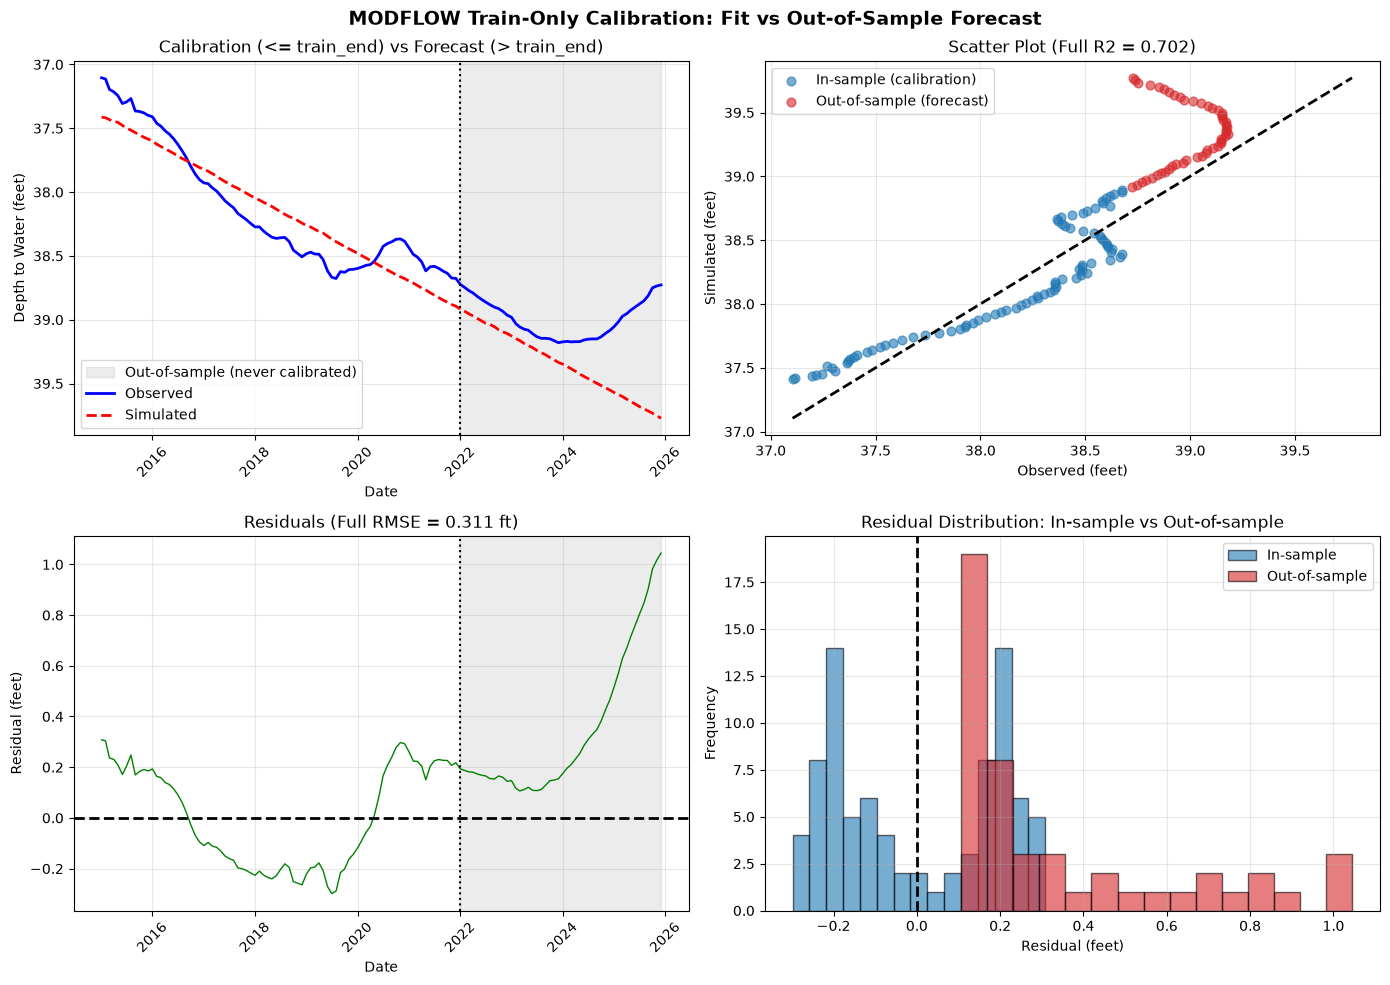


  WATER BUDGET (MASS-BALANCE CHECK) - CALIBRATED MODEL
  Mean daily rates in m3/day, by hydrological sub-period (Sec. 3.1.4)
                  Sub-period  Stress periods      Start        End  Storage In  Constant Head In  Wells In  Recharge In  Storage Out  Constant Head Out  Wells Out  Recharge Out  Total In  Total Out   In - Out  Storage Change (Out-In)  Mean % Discrepancy  Max |% Discrepancy|
2015-2021 (baseline decline)              84 2015-01-04 2021-12-01    270.1137          2.422788       0.0    91.534035          0.0          154.04767  209.15479           0.0 364.07056  363.20245  0.8680623                -270.1137          0.24726191                0.810
2022-2023 (extreme drawdown)              24 2022-01-01 2023-12-01   280.72498               0.0       0.0    100.13619          0.0          170.75835   209.1548           0.0 380.86118  379.91318 0.94802094               -280.72498          0.25666666                0.880
2024-2025 (partial recovery)              24 2024

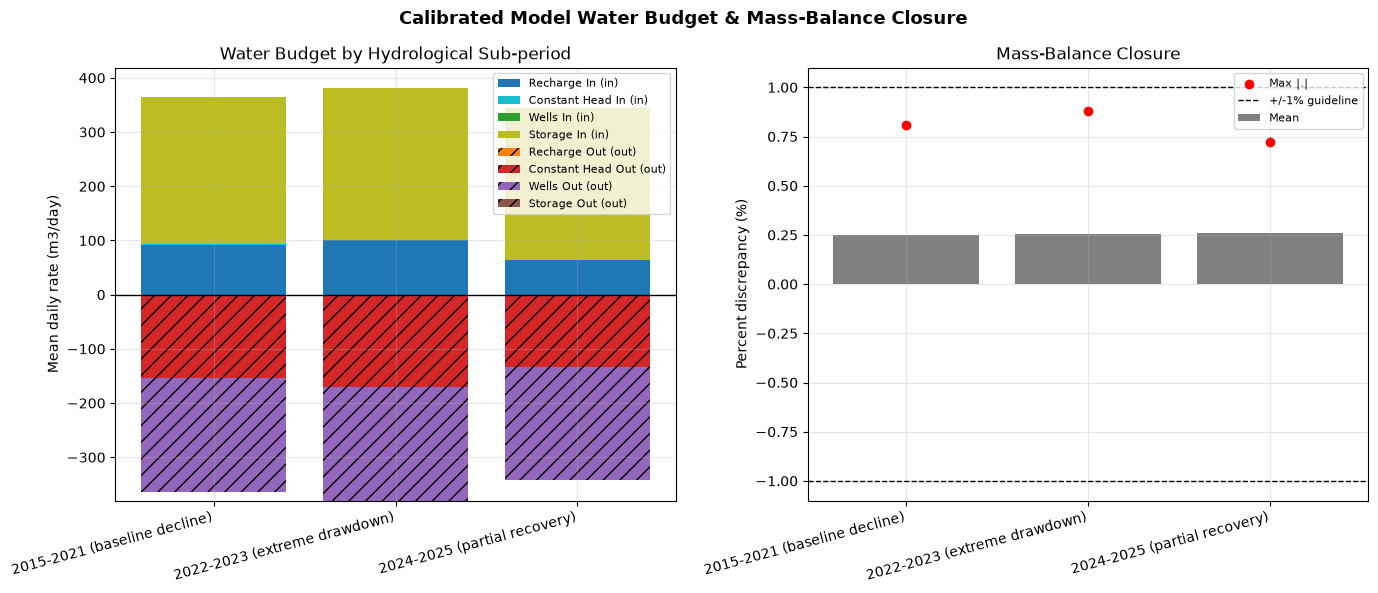


██████████████████████████████████████████████████████████████████████
   TRAIN-ONLY CALIBRATION + OUT-OF-SAMPLE FORECAST COMPLETE!
██████████████████████████████████████████████████████████████████████

CALIBRATED PARAMETERS (train-only, 2015-2021, seed=42)
  hk: 95.2064
  sy: 0.0500
  strt: 88.6237
  rch_mult: 0.1693
  pumping: -209.1548

  Out-of-sample metrics by sub-period:
    models/modflow_train_only/metrics_by_subperiod.csv
    models/modflow_train_only/train_only_calibration_results.png

  Water-budget table (recharge in, pumping out, boundary flux,
  storage change) for the full-record forward run is in:
    models/modflow_train_only/water_budget_by_subperiod.csv
    models/modflow_train_only/water_budget_full_timeseries.csv
    models/modflow_train_only/water_budget_by_subperiod.png


In [10]:
# =============================================================================
# EXECUTION
# =============================================================================
if __name__ == "__main__":

    simulated, observed, metrics, params, water_budget, metrics_by_subperiod = run_train_only_modflow_pipeline(
        data_path=r'data/engineered/engineered_dataset.csv',
        model_dir=r'models/modflow_train_only',
        target_col='water_level',
        date_col='date',
        train_end='2021-12-31',   # calibration NEVER sees dates after this
        val_end='2023-12-31',
        exe_name=r'MF2005.1_12/MF2005.1_12/bin/mf2005.exe',
        recharge_fraction=0.15,
        reference_elevation=100.0,
        maxiter=80,
        popsize=15,
        seed=42,
    )

    if params:
        print("\n" + "="*50)
        print("CALIBRATED PARAMETERS (train-only, 2015-2021, seed=42)")
        print("="*50)
        for k, v in params.items():
            print(f"  {k}: {v:.4f}")
        print("\n  Out-of-sample metrics by sub-period:")
        print("    models/modflow_train_only/metrics_by_subperiod.csv")
        print("    models/modflow_train_only/train_only_calibration_results.png")
        print("\n  Water-budget table (recharge in, pumping out, boundary flux,")
        print("  storage change) for the full-record forward run is in:")
        print("    models/modflow_train_only/water_budget_by_subperiod.csv")
        print("    models/modflow_train_only/water_budget_full_timeseries.csv")
        print("    models/modflow_train_only/water_budget_by_subperiod.png")